In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
# df = pd.read_csv("/mnt/scratch/baburish/TPN-training/final/reconstruction/reco-logs/iterative-event_summary.csv")
df = pd.read_csv("/mnt/scratch/baburish/TPN-training/final/TPN_God/reco-logs/22645_255epoch_linefit_iterative.csv")
dfe = pd.read_csv("/mnt/scratch/baburish/TPN-training/final/TPN_God/reco-logs/22645_255epoch_linefit_iterative_energy.csv")

In [29]:
# df = np.load('/mnt/scratch/baburish/TPN-training/final/reconstruction/event_scan_data.pkl', allow_pickle=True)

In [30]:
len(df)

1044

In [5]:
len(dfe)

2247

In [6]:
df2 = dfe.iloc[: len(df)]
len(df2)

1044

In [8]:
np.max(df2["muon_energy"])

9.99637239053424

In [9]:
lfit_ang_err = df["linefit_ang_err"].to_numpy()
splinempe_ang_err = df["splinempe_ang_err"].to_numpy()
al = []
sl = []
lfit_ang_err[0]

0.2846929072497555

In [10]:
j = 0
k = 0
l = 0
print("Total number of events:", len(df))
for i in range(len(lfit_ang_err)):
    if splinempe_ang_err[i] > 1.5 * lfit_ang_err[i]:
        l += 1
        continue
    elif lfit_ang_err[i] > splinempe_ang_err[i]:
        j += 1
        al.append(lfit_ang_err[i])
        sl.append(splinempe_ang_err[i])
    else:
        k += 1
        al.append(lfit_ang_err[i])
        sl.append(splinempe_ang_err[i])
print(f"LineFit better: {j} events, SplineMPE better: {k} events, Neither better: {l} events")
# splinempe_ang_err = np.array(sl)
# lfit_ang_err = np.array(al)

Total number of events: 1044
LineFit better: 557 events, SplineMPE better: 337 events, Neither better: 150 events


In [11]:
val=df["true dir"].iloc[0]
val.strip("[]")
arr = np.fromstring(val.strip("[]"), sep=", ")

def parse_dir(val):
    """Convert '[az  zen]' string → (azimuth, zenith) floats."""
    if isinstance(val, (list, np.ndarray)):
        return float(val[0]), float(val[1])
    arr = np.fromstring(val.strip("[]"), sep=", ")
    return float(arr[0]), float(arr[1])

for i in range(len(df["true dir"])):
    v = df["true dir"].iloc[i]
    try:
    #    print(parse_dir(v))
        aasdad=(parse_dir(v))
    except Exception as e:
        print(f"Error parsing {v} for id {i}: {e}")
        print(df["true dir"].iloc[i])

# true_az  = np.array([parse_dir(v)[0] for v in df["true dir"]])
# true_zen = np.array([parse_dir(v)[1] for v in df["true dir"]])


Angular error — linefit  (median): 0.53°
Angular error — splinempe (median): 0.53°

Saved → angular_resolution.png


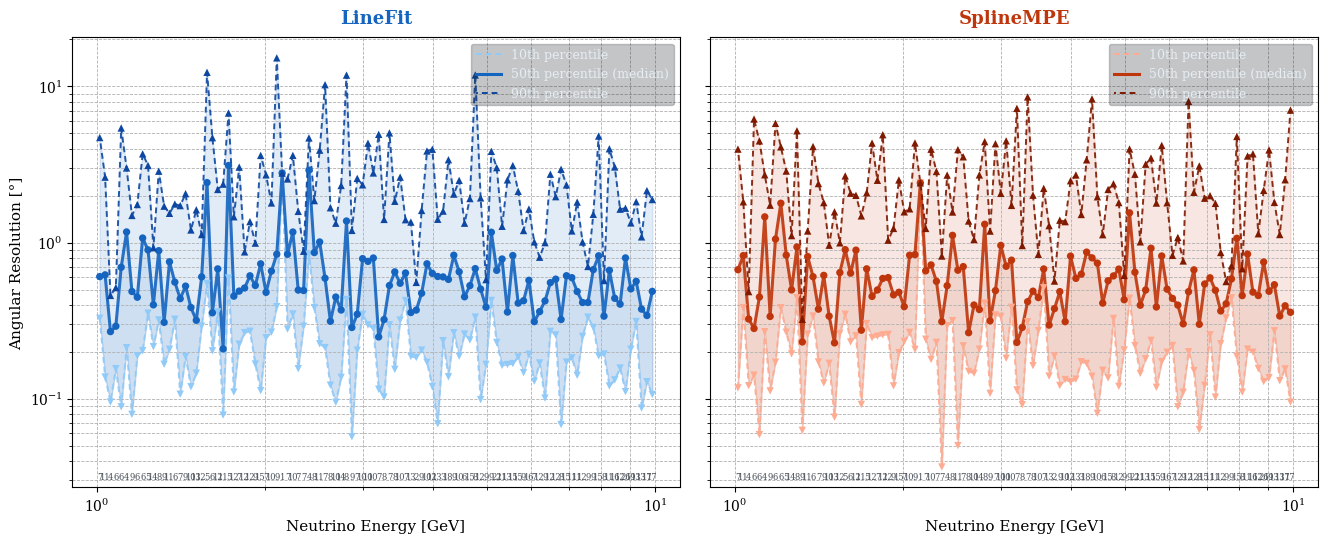


── Overall angular resolution summary ──
LineFit       median=0.53°  10th=0.14°  90th=2.66°
SplineMPE     median=0.53°  10th=0.13°  90th=2.64°


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u

# ── Load data ────────────────────────────────────────────────────────────────
# df = pd.read_csv("/mnt/scratch/baburish/TPN-training/final/reconstruction/reco-logs/iterative-event_summary.csv")

# ── Parse direction columns ───────────────────────────────────────────────────
# def parse_dir(val):
#     """Convert '[az  zen]' string → (azimuth, zenith) floats."""
#     if isinstance(val, (list, np.ndarray)):
#         return float(val[0]), float(val[1])
#     arr = np.fromstring(val.strip("[]"), sep=", ")
#     return float(arr[0]), float(arr[1])

# def zenith_to_declination(zenith_deg):
#     """
#     Convert zenith (polar angle from +z, degrees) → declination.
#       dec = 90° - zenith
#     Valid zenith range: [0°, 180°] → dec range: [+90°, -90°]
#     Values outside [0°,180°] indicate upstream wrapping issues in the data.
#     We wrap zenith into [0°,180°] before converting.
#     """
#     zen = np.asarray(zenith_deg, dtype=float)
#     # Wrap into [0°, 360°] then fold upper half back
#     zen = zen % 360.0
#     zen = np.where(zen > 180.0, 360.0 - zen, zen)
#     return 90.0 - zen

# # Extract az/zen arrays for each direction column

# true_az  = np.array([parse_dir(v)[0] for v in df["true dir"]])
# true_zen = np.array([parse_dir(v)[1] for v in df["true dir"]])

# reco_az  = np.array([parse_dir(v)[0] for v in df["linefit best dir"]])
# reco_zen = np.array([parse_dir(v)[1] for v in df["linefit best dir"]])

# spe_az   = np.array([parse_dir(v)[0] for v in df["splinempe best dir"]])
# spe_zen  = np.array([parse_dir(v)[1] for v in df["splinempe best dir"]])

# # Diagnostics
# print(f"Zenith range — true:     {true_zen.min():.2f}° – {true_zen.max():.2f}°")
# print(f"Zenith range — linefit:  {reco_zen.min():.2f}° – {reco_zen.max():.2f}°")
# print(f"Zenith range — splinempe:{spe_zen.min():.2f}° – {spe_zen.max():.2f}°")

# # Convert zenith → declination (vectorised, with wrapping)
# true_dec = zenith_to_declination(true_zen)
# reco_dec = zenith_to_declination(reco_zen)
# seed_dec = zenith_to_declination(spe_zen)

# print(f"Declination range — true: {true_dec.min():.2f}° – {true_dec.max():.2f}°")

# # Store in dataframe for downstream use
# df["true dir_az"],           df["true dir_zen"]           = true_az,  true_zen
# df["linefit best dir_az"],   df["linefit best dir_zen"]   = reco_az,  reco_zen
# df["splinempe seed dir_az"], df["splinempe seed dir_zen"] = spe_az,   spe_zen

# # ── Angular separation via SkyCoord ──────────────────────────────────────────
# def angular_sep_deg(az1, zen1, az2, zen2):
#     """Great-circle separation. zen = polar angle from +z (degrees)."""
#     lat1 = zenith_to_declination(zen1)
#     lat2 = zenith_to_declination(zen2)
#     # Wrap azimuth into [0°, 360°]
#     az1 = np.asarray(az1) % 360.0
#     az2 = np.asarray(az2) % 360.0
    
#     c1 = SkyCoord(az1 * u.deg, lat1 * u.deg, frame="icrs")
#     c2 = SkyCoord(az2 * u.deg, lat2 * u.deg, frame="icrs")
#     return c1.separation(c2).deg

# df["linefit_ang_err"] = angular_sep_deg(
#     df["true dir_az"].values, df["true dir_zen"].values,
#     df["linefit best dir_az"].values, df["linefit best dir_zen"].values,
# )
# df["splinempe_ang_err"] = angular_sep_deg(
#     df["true dir_az"].values, df["true dir_zen"].values,
#     df["splinempe seed dir_az"].values, df["splinempe seed dir_zen"].values,
# )


print(f"\nAngular error — linefit  (median): {df['linefit_ang_err'].median():.2f}°")
print(f"Angular error — splinempe (median): {df['splinempe_ang_err'].median():.2f}°")

# ── Energy bins (log-spaced) ──────────────────────────────────────────────────
# log_e = np.log10(df["neutrino_energy"].values)
log_e = np.log10(df2["muon_energy"].values)
n_bins = max(6, len(df2) // 10)
# n_bins = 20
bins = np.linspace(log_e.min(), log_e.max(), n_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_energies = 10 ** bin_centers

PERCENTILES = [10, 50, 90]
# COLORS = {
#     "linefit":   {"10": "#4fc3f7", "50": "#0288d1", "90": "#01579b"},
#     "splinempe": {"10": "#ff8a65", "50": "#e64a19", "90": "#7f1900"},
# }
COLORS = {
    "linefit":   {"10": "#90caf9", "50": "#1565c0", "90": "#0d47a1"},
    "splinempe": {"10": "#ffab91", "50": "#bf360c", "90": "#7f1900"},
}
def binned_percentiles(errors, log_e_vals, bins, pcts):
    result = {p: [] for p in pcts}
    counts = []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (log_e_vals >= lo) & (log_e_vals < hi)
        counts.append(mask.sum())
        for p in pcts:
            result[p].append(np.percentile(errors[mask], p) if mask.sum() > 0 else np.nan)
    return {p: np.array(result[p]) for p in pcts}, np.array(counts)

lf_pcts,  lf_counts  = binned_percentiles(df["linefit_ang_err"].values,  log_e, bins, PERCENTILES)
spe_pcts, spe_counts = binned_percentiles(df["splinempe_ang_err"].values, log_e, bins, PERCENTILES)

# ── Plot ──────────────────────────────────────────────────────────────────────
# plt.rcParams.update({
#     "font.family":      "serif",
#     "font.serif":       ["DejaVu Serif"],
#     "axes.facecolor":   "#0d1117",
#     "figure.facecolor": "#0d1117",
#     "axes.edgecolor":   "#30363d",
#     "axes.labelcolor":  "#e6edf3",
#     "xtick.color":      "#8b949e",
#     "ytick.color":      "#8b949e",
#     "text.color":       "#e6edf3",
#     "grid.color":       "#21262d",
#     "grid.linestyle":   "--",
#     "grid.linewidth":   0.6,
#     "axes.grid":        True,
#     "axes.grid.which":  "both",
# })
plt.rcParams.update({
    "font.family":     "serif",
    "font.serif":      ["DejaVu Serif"],
    "grid.linestyle":  "--",
    "grid.linewidth":  0.6,
    "axes.grid":       True,
    "axes.grid.which": "both",
})
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
fig.subplots_adjust(wspace=0.05, left=0.08, right=0.97, top=0.88, bottom=0.13)

ALPHA_FILL = 0.12
ALPHA_LINE = 0.9

def plot_algo(ax, pcts, bin_energies, counts, colors, label):
    from matplotlib.lines import Line2D
    p10, p50, p90 = pcts[10], pcts[50], pcts[90]

    ax.fill_between(bin_energies, p10, p90, color=colors["50"], alpha=ALPHA_FILL, zorder=1)
    ax.fill_between(bin_energies, p10, p50, color=colors["50"], alpha=ALPHA_FILL * 0.8, zorder=1)

    for p, key, ls, lw, mk in [
        (p10, "10", (5,(3,2)), 1.4, "v"),
        (p50, "50", "-",       2.2, "o"),
        (p90, "90", (2,(3,2)), 1.4, "^"),
    ]:
        ax.plot(bin_energies, p, color=colors[key], lw=lw, ls=ls, alpha=ALPHA_LINE, zorder=3)
        valid = ~np.isnan(p)
        ax.scatter(bin_energies[valid], p[valid], color=colors[key],
                   marker=mk, s=28, zorder=4, edgecolors="none")

    handles = [
        Line2D([0], [0], color=colors["10"], lw=1.4, ls=(5,(3,2)), label="10th percentile"),
        Line2D([0], [0], color=colors["50"], lw=2.2, ls="-",       label="50th percentile (median)"),
        Line2D([0], [0], color=colors["90"], lw=1.4, ls=(2,(3,2)), label="90th percentile"),
    ]
    leg = ax.legend(handles=handles, loc="upper right", fontsize=9,
                    framealpha=0.25, edgecolor="#30363d", facecolor="#161b22")
    for t in leg.get_texts():
        t.set_color("#e6edf3")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Neutrino Energy [GeV]", fontsize=11)
    ax.set_title(label, fontsize=13, pad=10, color=colors["50"], fontweight="bold")

    for e, c in zip(bin_energies, counts):
        if c > 0:
            ax.annotate(str(c), xy=(e, 0), fontsize=6, color="#484f58",
                        ha="center", va="bottom",
                        xycoords=("data", "axes fraction"),
                        xytext=(0, 4), textcoords="offset points")

plot_algo(axes[0], lf_pcts,  bin_energies, lf_counts,  COLORS["linefit"],   "LineFit")
plot_algo(axes[1], spe_pcts, bin_energies, spe_counts, COLORS["splinempe"], "SplineMPE")

axes[0].set_ylabel("Angular Resolution [°]", fontsize=11)

# fig.text(0.5, 0.95,
#          "Directional Reconstruction — Angular Resolution vs. Neutrino Energy",
#          ha="center", va="top", fontsize=14, color="#e6edf3", fontweight="bold")
# fig.text(0.5, 0.91,
#          "Shaded regions span 10th–90th percentile  ·  Numbers indicate events per bin",
#          ha="center", va="top", fontsize=9, color="black")

# plt.savefig("/mnt/user-data/outputs/angular_resolution.png",
#             dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
print("\nSaved → angular_resolution.png")
plt.show()

# ── Quick summary table ───────────────────────────────────────────────────────
print("\n── Overall angular resolution summary ──")
for algo, col in [("LineFit", "linefit_ang_err"), ("SplineMPE", "splinempe_ang_err")]:
    vals = df[col].dropna()
    print(f"{algo:12s}  "
          f"median={vals.median():.2f}°  "
          f"10th={np.percentile(vals,10):.2f}°  "
          f"90th={np.percentile(vals,90):.2f}°")

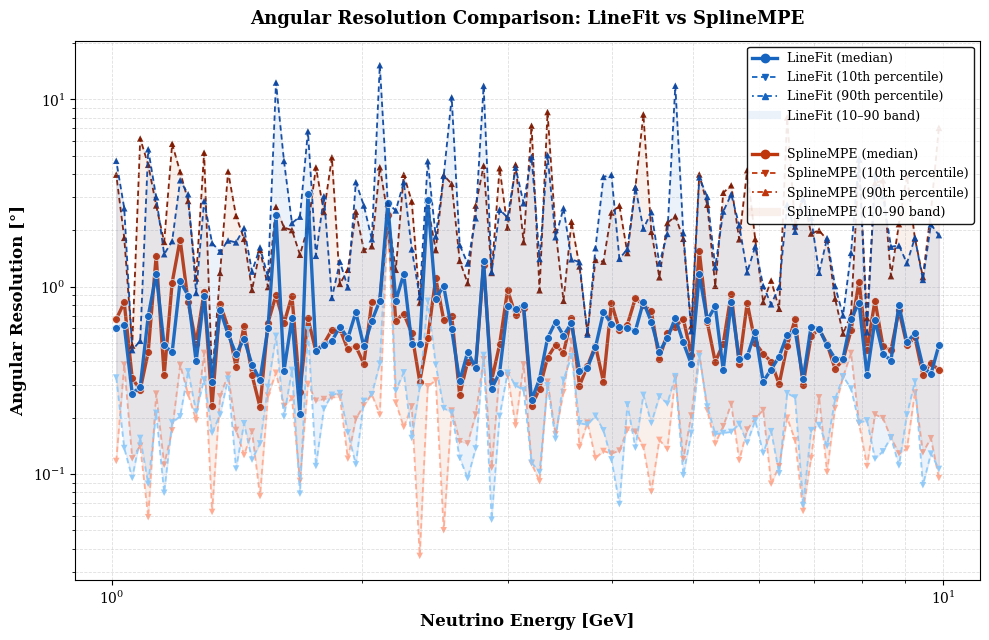


── Median angular resolution by energy bin ──

Energy (GeV)    LineFit (°)     SplineMPE (°)   Difference (°) 
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
1.0             0.605           0.670           -0.065           ✓ LF
1.0             0.621           0.825           -0.204           ✓ LF
1.1             0.269           0.324           -0.055           ✓ LF
1.1             0.291           0.282           0.009            ✓ SPE
1.1             0.695           0.448           0.247            ✓ SPE
1.1             1.170           1.461           -0.291           ✓ LF
1.2             0.486           0.336           0.150            ✓ SPE
1.2             0.447           1.052           -0.605           ✓ LF
1.2             1.069           1.787           -0.718           ✓ LF
1.2             0.898           0.831           0.067            ✓ SPE
1.3             0.399           0.497           -0.098           ✓ LF
1.3             0.887           0.937           -0.05

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Assuming you have: lf_pcts, spe_pcts, bin_energies, counts, COLORS already defined

# ── Improved Overlay Plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6.5))
fig.subplots_adjust(left=0.11, right=0.97, top=0.88, bottom=0.13)

ALPHA_FILL = 0.08
ALPHA_LINE = 0.95

# Plot each algorithm separately with clear ordering
algorithms = [
    (lf_pcts,  COLORS["linefit"],   "LineFit",   2),
    (spe_pcts, COLORS["splinempe"], "SplineMPE", 1),
]

# Store handles for legend
handles_list = []

for pcts, colors, algo_label, zorder_base in algorithms:
    p10, p50, p90 = pcts[10], pcts[50], pcts[90]
    
    # Fill band (semi-transparent)
    ax.fill_between(bin_energies, p10, p90, color=colors["50"], 
                     alpha=ALPHA_FILL, zorder=zorder_base, 
                     label=f"{algo_label} (10–90 percentile)")
    
    # Plot percentile lines with distinct styles
    # 10th percentile
    ax.plot(bin_energies, p10, color=colors["10"], lw=1.3, ls=(5,(3,2)), 
            alpha=ALPHA_LINE, zorder=zorder_base+0.1)
    valid = ~np.isnan(p10)
    ax.scatter(bin_energies[valid], p10[valid], color=colors["10"],
               marker="v", s=22, zorder=zorder_base+0.2, edgecolors="none", alpha=ALPHA_LINE)
    
    # 50th percentile (median) — thicker line
    ax.plot(bin_energies, p50, color=colors["50"], lw=2.4, ls="-", 
            alpha=ALPHA_LINE, zorder=zorder_base+0.1, label=f"{algo_label} median")
    valid = ~np.isnan(p50)
    ax.scatter(bin_energies[valid], p50[valid], color=colors["50"],
               marker="o", s=32, zorder=zorder_base+0.2, edgecolors="white", 
               linewidths=0.5, alpha=ALPHA_LINE)
    
    # 90th percentile
    ax.plot(bin_energies, p90, color=colors["90"], lw=1.3, ls=(2,(3,2)), 
            alpha=ALPHA_LINE, zorder=zorder_base+0.1)
    valid = ~np.isnan(p90)
    ax.scatter(bin_energies[valid], p90[valid], color=colors["90"],
               marker="^", s=22, zorder=zorder_base+0.2, edgecolors="none", alpha=ALPHA_LINE)

# Custom legend with explicit handles
handles = [
    # LineFit group
    Line2D([0], [0], color=COLORS["linefit"]["50"], lw=2.4, label="LineFit (median)", marker="o", markersize=6),
    Line2D([0], [0], color=COLORS["linefit"]["50"], lw=1.3, ls=(5,(3,2)), label="LineFit (10th percentile)", marker="v", markersize=5),
    Line2D([0], [0], color=COLORS["linefit"]["50"], lw=1.3, ls=(2,(3,2)), label="LineFit (90th percentile)", marker="^", markersize=5),
    Line2D([0], [0], color=COLORS["linefit"]["50"], alpha=ALPHA_FILL, linewidth=6, label="LineFit (10–90 band)"),
    
    # Spacer
    Line2D([0], [0], color="none"),
    
    # SplineMPE group
    Line2D([0], [0], color=COLORS["splinempe"]["50"], lw=2.4, label="SplineMPE (median)", marker="o", markersize=6),
    Line2D([0], [0], color=COLORS["splinempe"]["50"], lw=1.3, ls=(5,(3,2)), label="SplineMPE (10th percentile)", marker="v", markersize=5),
    Line2D([0], [0], color=COLORS["splinempe"]["50"], lw=1.3, ls=(2,(3,2)), label="SplineMPE (90th percentile)", marker="^", markersize=5),
    Line2D([0], [0], color=COLORS["splinempe"]["50"], alpha=ALPHA_FILL, linewidth=6, label="SplineMPE (10–90 band)"),
]

leg = ax.legend(handles=handles, loc="upper right", fontsize=9, ncol=1,
                framealpha=0.9, edgecolor="black", facecolor="white")

# Axis styling
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Neutrino Energy [GeV]", fontsize=12, fontweight="bold")
ax.set_ylabel("Angular Resolution [°]", fontsize=12, fontweight="bold")
ax.set_title("Angular Resolution Comparison: LineFit vs SplineMPE", 
             fontsize=13, fontweight="bold", pad=12)

ax.grid(True, which="both", linestyle="--", linewidth=0.6, alpha=0.4)

plt.tight_layout()
# plt.savefig("/mnt/user-data/outputs/angular_resolution_overlay_fixed.png", 
#             dpi=180, bbox_inches="tight")
# print("Saved → angular_resolution_overlay_fixed.png")
plt.show()

# ── Print comparison ──────────────────────────────────────────────────────────
print("\n── Median angular resolution by energy bin ──\n")
print(f"{'Energy (GeV)':<15} {'LineFit (°)':<15} {'SplineMPE (°)':<15} {'Difference (°)':<15}")
print("–" * 60)
for e, lf_med, spe_med in zip(bin_energies, lf_pcts[50], spe_pcts[50]):
    if not (np.isnan(lf_med) or np.isnan(spe_med)):
        diff = lf_med - spe_med
        better = "✓ SPE" if diff > 0 else "✓ LF"
        print(f"{e:<15.1f} {lf_med:<15.3f} {spe_med:<15.3f} {diff:<15.3f}  {better}")

In [33]:
# Which bins have the fewest events?
print("\nBin event counts:")
for e, lf_c, spe_c in zip(bin_energies, lf_counts, spe_counts):
    print(f"{e:.0f} GeV: {lf_c:4d} events")

# Recompute overall median directly from raw data
print(f"\nDirect median from full dataset:")
print(f"  LineFit:   {df['linefit_ang_err'].median():.3f}°")
print(f"  SplineMPE: {df['splinempe_ang_err'].median():.3f}°")


Bin event counts:
1 GeV:    7 events
1 GeV:   11 events
1 GeV:    4 events
1 GeV:    6 events
1 GeV:    6 events
1 GeV:    4 events
1 GeV:    9 events
1 GeV:    6 events
1 GeV:    6 events
1 GeV:    5 events
1 GeV:   14 events
1 GeV:    8 events
1 GeV:    9 events
1 GeV:   11 events
1 GeV:    6 events
1 GeV:    7 events
1 GeV:    9 events
1 GeV:   10 events
2 GeV:   13 events
2 GeV:   12 events
2 GeV:    5 events
2 GeV:    6 events
2 GeV:   12 events
2 GeV:   11 events
2 GeV:    5 events
2 GeV:   12 events
2 GeV:    7 events
2 GeV:   12 events
2 GeV:   12 events
2 GeV:    9 events
2 GeV:   15 events
2 GeV:    7 events
2 GeV:   10 events
2 GeV:    9 events
2 GeV:    1 events
2 GeV:    7 events
2 GeV:   10 events
2 GeV:    7 events
2 GeV:    7 events
2 GeV:    4 events
2 GeV:    8 events
3 GeV:   11 events
3 GeV:    7 events
3 GeV:    8 events
3 GeV:   10 events
3 GeV:   14 events
3 GeV:    8 events
3 GeV:    9 events
3 GeV:    7 events
3 GeV:   10 events
3 GeV:   10 events
3 GeV:   10 

Saved → angular_resolution_simple.png


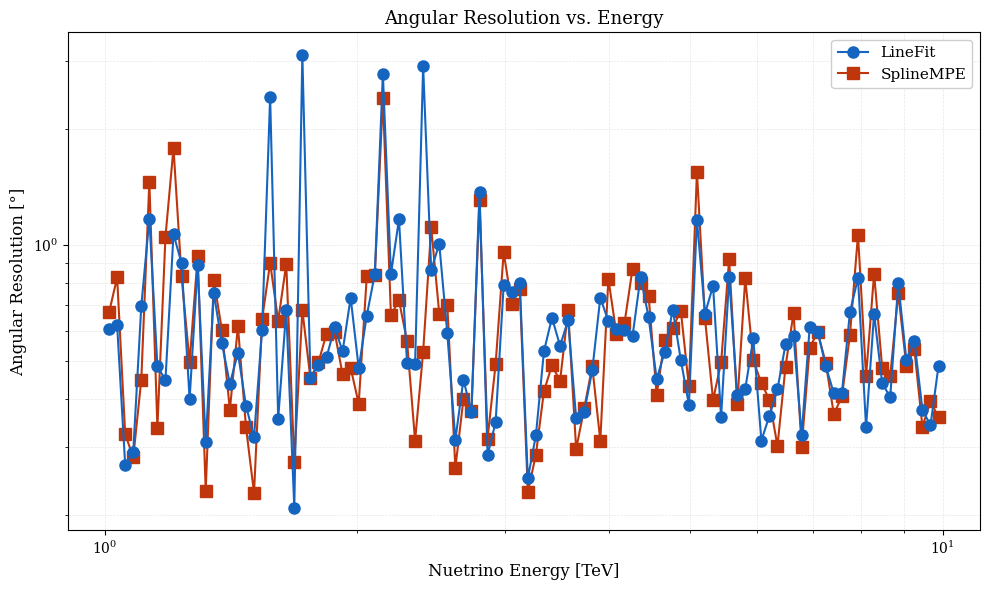

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
 
# ── Simple overlay plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
fig.subplots_adjust(left=0.11, right=0.97, top=0.92, bottom=0.12)
 
COLORS = {
    "linefit":   {"50": "#1565c0"},
    "splinempe": {"50": "#bf360c"},
}
 
# Plot median (50th percentile) for each algorithm
ax.plot(bin_energies, lf_pcts[50], color=COLORS["linefit"]["50"], 
        lw=1.5, marker="o", markersize=8, label="LineFit", zorder=3)
 
ax.plot(bin_energies, spe_pcts[50], color=COLORS["splinempe"]["50"], 
        lw=1.5, marker="s", markersize=8, label="SplineMPE", zorder=2)
 
# Styling
ax.set_xscale("log")
ax.set_yscale("log")
# ax.set_xlabel("Muon Energy at Detector Entry[TeV]", fontsize=12)
ax.set_xlabel("Nuetrino Energy [TeV]", fontsize=12)
ax.set_ylabel("Angular Resolution [°]", fontsize=12)
ax.set_title("Angular Resolution vs. Energy", fontsize=13)
 
ax.legend(fontsize=11, loc="upper right", framealpha=0.95)
ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.3)
 
plt.tight_layout()
# plt.savefig("/mnt/user-data/outputs/angular_resolution_simple.png", dpi=180, bbox_inches="tight")
print("Saved → angular_resolution_simple.png")
plt.show()

In [115]:
def parse_dir(s):
    vals = s.strip("[]").split()
    return float(vals[0]), float(vals[1])

# Parse directions
true_lon, true_lat = zip(*df["true dir"].apply(parse_dir))
reco_lon, reco_lat = zip(*df["linefit best dir"].apply(parse_dir))
seed_lon, seed_lat = zip(*df["splinempe best dir"].apply(parse_dir))

ValueError: could not convert string to float: '99.78331082071418,'

In [87]:
# true_lon, true_lat = zip(*df["True Direction (deg)"])
# reco_lon, reco_lat = zip(*df["Direction (deg)"])
# seed_lon, seed_lat = zip(*df["Seed Direction (deg)"])

In [88]:
# def parse_dir(s):
#     vals = s.strip("[]").split()
#     return float(vals[0]), float(vals[1])

# # Parse directions
# true_lon, true_lat = zip(*df["True Direction (deg)"].apply(parse_dir))
# reco_lon, reco_lat = zip(*df["Direction (deg)"].apply(parse_dir))
# seed_lon, seed_lat = zip(*df["Seed Direction (deg)"].apply(parse_dir))

In [89]:
def zenith_to_declination(zenith):
    declination = zenith - 90
    return declination

def GreatCircleDistance(az1, dec1, az2, dec2):
    """
    Compute the great circle distance between two points on a sphere.

    Parameters:
        az1, dec1: coordinates of the first point (in degrees)
        az2, dec2: coordinates of the second point (in degrees)
    
    Returns:
        distance: great circle distance in degrees
    """
    # Convert to radians
    az1 = np.radians(az1)
    dec1 = np.radians(dec1)
    az2 = np.radians(az2)
    dec2 = np.radians(dec2)

    # Spherical law of cosines
    cos_angle = np.sin(dec1)*np.sin(dec2) + np.cos(dec1)*np.cos(dec2)*np.cos(az1 - az2)
    cos_angle = np.clip(cos_angle, -1, 1)  # Avoid numerical errors
    angle = np.arccos(cos_angle)

    # Convert back to degrees
    return np.degrees(angle)



In [91]:
# true_az, true_zen = zip(*df["true dir"].apply(parse_dir))
# reco_az, reco_zen = zip(*df["reco dir"].apply(parse_dir))
# seed_az, seed_zen = zip(*df["seed dir"].apply(parse_dir))
# true_az, true_zen = zip(*df["True Direction (deg)"])
# reco_az, reco_zen = zip(*df["Direction (deg)"])
# seed_az, seed_zen = zip(*df["Seed Direction (deg)"])
# true_lon, true_lat = zip(*df["true dir"].apply(parse_dir))
# reco_lon, reco_lat = zip(*df["linefit best dir"].apply(parse_dir))
# seed_lon, seed_lat = zip(*df["splinempe best dir"].apply(parse_dir))

true_az, true_zen = zip(*df["true dir"].apply(parse_dir))
reco_az, reco_zen = zip(*df["linefit best dir"].apply(parse_dir))
seed_az, seed_zen = zip(*df["splinempe best dir"].apply(parse_dir))

true_dec = []
seed_dec = []
reco_dec = []

for i in true_zen:
    true_dec.append(zenith_to_declination(i))
for i in seed_zen:
    seed_dec.append(zenith_to_declination(i))
for i in reco_zen:
    reco_dec.append(zenith_to_declination(i))
df['reco_angular_sep'] = GreatCircleDistance(true_az,
                                        true_dec,
                                        reco_az,
                                        reco_dec)

In [92]:
df['spline_angular_sep'] = GreatCircleDistance(true_az,
                                        true_dec,
                                        seed_az,
                                        seed_dec)

In [93]:
np.median(np.rad2deg(df['reco_angular_sep']))


40.32371453516177

In [94]:
np.median(np.rad2deg(df['spline_angular_sep'] ))

29.92719980126366

In [95]:
print('Reco median res = ',np.median((df['reco_angular_sep'])))
print('Spline median res = ',np.median((df['spline_angular_sep'])))

Reco median res =  0.7037815852728677
Spline median res =  0.5223281724342436


In [96]:
# some plotting adjustments
def adjust_plot_2d(fig, ax, pc, plot_args=None):
    if not plot_args:
        plot_args = {}
    
    pc.set_cmap(plot_args.get('cmap', 'cubehelix'))
    ax.set_ylabel(plot_args.get('ylabel', 'var 2'), position=(0., 1.), va='top', ha='right', size=20)
    ax.set_xlabel(plot_args.get('xlabel', 'var 1'), position=(1., 0.), va='bottom', ha='right', size=20)
    ax.yaxis.set_label_coords(-0.2, 1.)
    ax.xaxis.set_label_coords(1.0, -0.2)
    ax.tick_params(axis='y', which='major', labelsize=18, pad=5)
    ax.tick_params(axis='x', which='major', labelsize=18, pad=5)
    fig.subplots_adjust(right=0.78)
    cbar_ax1 = fig.add_axes([0.81, 0.1, 0.04, 0.79])
    cbar = fig.colorbar(pc, cbar_ax1)
    cbar.ax.tick_params(labelsize=18)
    cbar.set_label(plot_args.get('zlabel', 'pdf'), rotation=270, fontsize=18, labelpad=25)
    ax.set_ylim(plot_args.get('ylim', [0, 1]))
    ax.set_xlim(plot_args.get('xlim', [0, 1]))
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(1.5)
        ax.spines[axis].set_color('0.0')
    ax.yaxis.set_ticks_position('both')

    
def adjust_plot_1d(fig, ax, plot_args=None):
    if not plot_args:
        plot_args = {}

    for axis in ['top','bottom','left','right']:
          ax.spines[axis].set_linewidth(1.5)
          ax.spines[axis].set_color('0.0')

    y_scale_in_log = plot_args.get('y_axis_in_log', False)
    if(y_scale_in_log):
        ax.set_yscale('log')

    ax.tick_params(axis='both', which='both', width=1.5, colors='0.0', labelsize=18)
    ax.yaxis.set_ticks_position('both')
    ax.set_ylabel(plot_args.get('ylabel', 'pdf'), fontsize=20)
    ax.set_xlabel(plot_args.get('xlabel', 'var 1'), fontsize=20)
    ax.legend(fontsize=15, loc='upper right')
    ax.set_ylim(plot_args.get('ylim', [0, 1]))
    ax.set_xlim(plot_args.get('xlim', [0, 1]))

In [97]:
e_nu_range = [4, 6]
e_nu_bins = np.linspace(*e_nu_range, 16)
e_nu_widths = np.diff(e_nu_bins) 

dpsi_range = [0.0, 3.0]
dpsi_bins = np.linspace(*dpsi_range, 31)
dpsi_widths = np.diff(dpsi_bins)

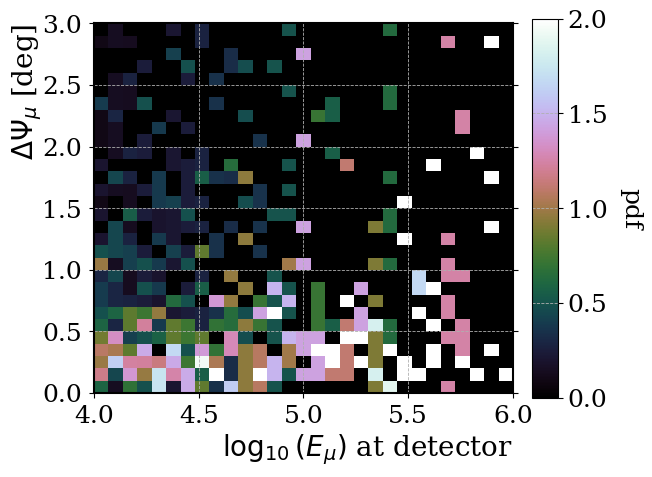

In [98]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# 1. Bin definitions
e_nu_range = [4, 6]
e_nu_bins = np.linspace(*e_nu_range, 30)
e_nu_centers = 0.5 * (e_nu_bins[:-1] + e_nu_bins[1:])
e_nu_widths = np.diff(e_nu_bins)

dpsi_range = [0.0, 3.0]
dpsi_bins = np.linspace(*dpsi_range, 31)
dpsi_centers = 0.5 * (dpsi_bins[:-1] + dpsi_bins[1:])
dpsi_widths = np.diff(dpsi_bins)

# 2. Joint histogram (counts, not density)
hist_joint_mg, _ = np.histogramdd(
    [np.log10(df['neutrino_energy']), df['reco_angular_sep']],
    bins=[e_nu_bins, dpsi_bins],
    density=False
)

# 3. Convert bin counts → PDF
hist_joint_mg = hist_joint_mg / (
    np.sum(hist_joint_mg * e_nu_widths[:, None] * dpsi_widths[None, :])
)

# 3. Marginal over dpsi for each energy bin (shape: n_e x 1)
hist_marginal_e = np.sum(hist_joint_mg * dpsi_widths[None, :], axis=1, keepdims=True)

# 4. Conditional PDF: P(dpsi | E)
hist_cond_mg = hist_joint_mg / hist_marginal_e  # units: 1/deg

# 6. Plotting
fig, ax = plt.subplots()

X, Y = np.meshgrid(e_nu_centers, dpsi_centers)

pc = ax.pcolormesh(
    X, Y, hist_cond_mg.T,
    norm=matplotlib.colors.Normalize(vmin=0.0, vmax=2),
    shading='auto'
)

plot_args = {
    'xlim': e_nu_range,
    'ylim': dpsi_range,
    'xlabel': '$\log_{10}(E_{\mu})$ at detector',
    'ylabel': '$\Delta \Psi_{\mu}$ [deg]'
}
adjust_plot_2d(fig, ax, pc, plot_args=plot_args)

plt.show()


In [99]:
def get_quantiles(dpsi, energy, e_bins):
    lower, med, upper = [], [], []
    for el, eh in zip(e_bins[:-1], e_bins[1:]):
        print(el, eh)
        idx = np.logical_and(energy >= el, energy < eh)
        # n_events = np.sum(idx)
        # print(f"{el:.2e}–{eh:.2e} GeV: {n_events} events")
        l, m, u = np.percentile(dpsi[idx], [10, 50, 90])
        lower.append(l)
        med.append(m)
        upper.append(u)
        
    return lower, med, upper

In [100]:
import numpy as np

def get_quantiles(values, energy, e_bins, qs=[10, 50, 90]):
    values = np.asarray(values)
    energy = np.asarray(energy)

    out = [[] for _ in qs]

    for el, eh in zip(e_bins[:-1], e_bins[1:]):
        idx = (energy >= el) & (energy < eh)

        if not np.any(idx):
            # no events → fill with NaN
            for arr in out:
                arr.append(np.nan)
            continue

        qv = np.percentile(values[idx], qs)
        for arr, v in zip(out, qv):
            arr.append(v)

    return out

In [101]:
# lower, med, upper = get_quantiles(df['reco_angular_sep'], np.log10(df['neutrino_energy']), e_nu_bins)

# lower_s, med_s, upper_s = get_quantiles(df['spline_angular_sep'], np.log10(df['neutrino_energy']), e_nu_bins)
lower, med, upper = get_quantiles(df['reco_angular_sep'], 
                                  np.log10(df['neutrino_energy']), 
                                  e_nu_bins)
lower_s, med_s, upper_s = get_quantiles(df['spline_angular_sep'], 
                                        np.log10(df['neutrino_energy']),
                                        e_nu_bins)

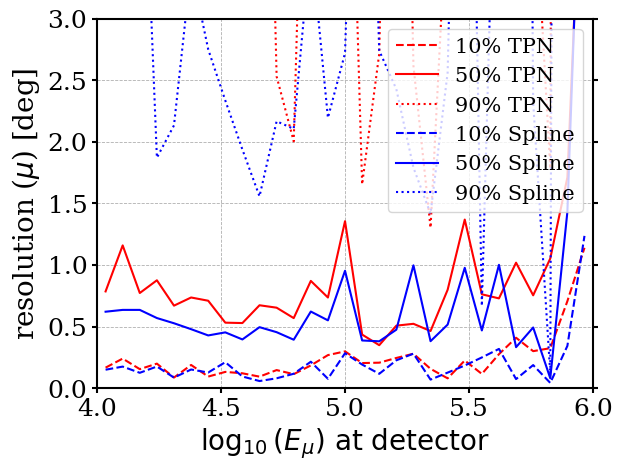

In [102]:

lower     = np.array(lower)
med       = np.array(med)
upper     = np.array(upper)

lower_s   = np.array(lower_s)
med_s     = np.array(med_s)
upper_s   = np.array(upper_s)

# Energy bin centers
centers = lambda x: 0.5 * (x[:-1] + x[1:])
e_nu_centers = centers(e_nu_bins)

fig, ax = plt.subplots()

plot_args = {
    'xlabel' : r'$\log_{10}(E_{\mu})\,\,\text{at detector}$',
    'ylabel' : r'resolution ($\mu$) [deg]',
    'xlim'   : [4.0, 6.0],
    'ylim'   : [0.0, 3.0]
}

# --- TPN (red) ---
ax.plot(e_nu_centers, lower, color='red', linestyle='dashed', label='10% TPN')
ax.plot(e_nu_centers, med,   color='red', linestyle='solid',  label='50% TPN')
ax.plot(e_nu_centers, upper, color='red', linestyle='dotted', label='90% TPN')

# --- Spline (blue) ---
ax.plot(e_nu_centers, lower_s, color='blue', linestyle='dashed', label='10% Spline')
ax.plot(e_nu_centers, med_s,   color='blue', linestyle='solid',  label='50% Spline')
ax.plot(e_nu_centers, upper_s, color='blue', linestyle='dotted', label='90% Spline')

# Apply your custom styling
adjust_plot_1d(fig, ax, plot_args=plot_args)

plt.show()

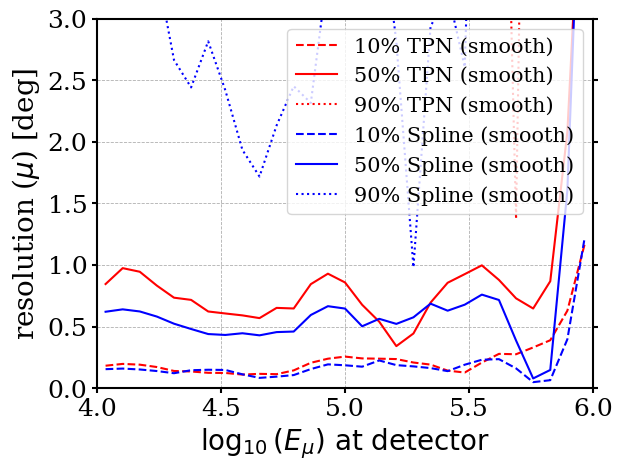

In [103]:
from scipy.signal import savgol_filter

def smooth_curve(y, window=7, poly=3):
    y = np.array(y, dtype=float)

    # window length must be odd & <= len(y)
    if len(y) < window:
        window = len(y) if len(y) % 2 == 1 else len(y)-1
    
    # If still invalid, return unsmoothed
    if window < 3:
        return y
    
    return savgol_filter(y, window_length=window, polyorder=poly)
lower_smooth   = smooth_curve(lower)
med_smooth     = smooth_curve(med)
upper_smooth   = smooth_curve(upper)

lower_s_smooth = smooth_curve(lower_s)
med_s_smooth   = smooth_curve(med_s)
upper_s_smooth = smooth_curve(upper_s)
fig, ax = plt.subplots()

# TPN (red)
ax.plot(e_nu_centers, lower_smooth, color='red', linestyle='dashed', label='10% TPN (smooth)')
ax.plot(e_nu_centers, med_smooth,   color='red', linestyle='solid',  label='50% TPN (smooth)')
ax.plot(e_nu_centers, upper_smooth, color='red', linestyle='dotted', label='90% TPN (smooth)')

# Spline (blue)
ax.plot(e_nu_centers, lower_s_smooth, color='blue', linestyle='dashed', label='10% Spline (smooth)')
ax.plot(e_nu_centers, med_s_smooth,   color='blue', linestyle='solid',  label='50% Spline (smooth)')
ax.plot(e_nu_centers, upper_s_smooth, color='blue', linestyle='dotted', label='90% Spline (smooth)')

adjust_plot_1d(fig, ax, plot_args=plot_args)
plt.show()

In [105]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# ── Unpack directions ─────────────────────────────────────────────────────────
# true_az,  true_zen  = np.radians(np.array(list(zip(*df["True Direction (deg)"]))))
# reco_az,  reco_zen  = np.radians(np.array(list(zip(*df["Direction (deg)"]))))
# seed_az,  seed_zen  = np.radians(np.array(list(zip(*df["Seed Direction (deg)"]))))

true_az,  true_zen  = np.radians(np.array(list(zip(*df["true dir"].apply(parse_dir)))))
reco_az,  reco_zen  = np.radians(np.array(list(zip(*df["linefit best dir"].apply(parse_dir)))))
seed_az,  seed_zen  = np.radians(np.array(list(zip(*df["splinempe best dir"].apply(parse_dir)))))
# true_az, true_zen = zip(*df["true dir"].apply(parse_dir))
# reco_az, reco_zen = zip(*df["linefit best dir"].apply(parse_dir))
# seed_az, seed_zen = zip(*df["splinempe best dir"].apply(parse_dir))
# ── Angular errors (already computed in your df) ──────────────────────────────
dpsi_A  = df['reco_angular_sep'].values    # Method A: reco vs truth
dpsi_B  = df['spline_angular_sep'].values  # Method B: spline vs truth

# ── Opening angle between A and B ─────────────────────────────────────────────
def angular_sep(zen1, az1, zen2, az2):
    """Inputs in radians, output in degrees."""
    cos_angle = (np.cos(zen1) * np.cos(zen2) +
                 np.sin(zen1) * np.sin(zen2) * np.cos(az1 - az2))
    return np.degrees(np.arccos(np.clip(cos_angle, -1, 1)))

dpsi_AB   = angular_sep(reco_zen, reco_az, seed_zen, seed_az)  # reco vs seed
dpsi_seed = angular_sep(seed_zen, seed_az, true_zen, true_az)  # seed vs truth (useful baseline)

# ── Signed bias components ────────────────────────────────────────────────────
def wrap(d):
    return (d + 180) % 360 - 180

dzen_A = np.degrees(reco_zen - true_zen)
daz_A  = wrap(np.degrees(reco_az - true_az))
dzen_B = np.degrees(seed_zen - true_zen)   # seed is your "method B" input
daz_B  = wrap(np.degrees(seed_az - true_az))

# ── Energy ────────────────────────────────────────────────────────────────────
log_energy = np.log10(df['neutrino_energy'].values)

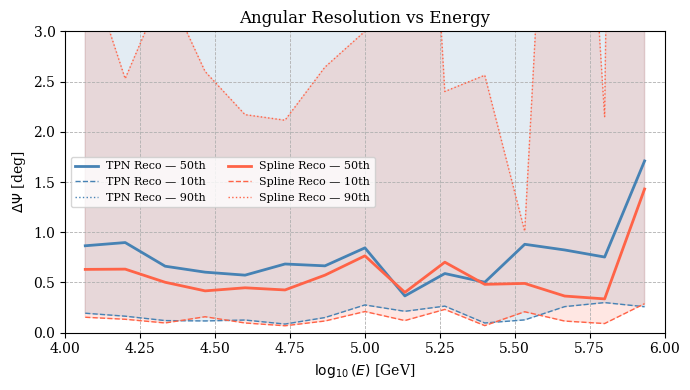

/tmp/ipykernel_1259147/1364205015.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


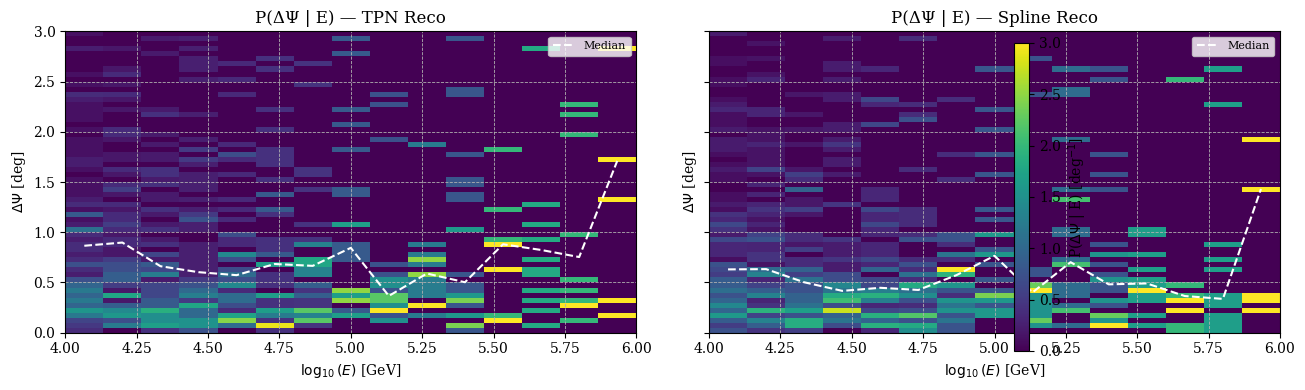

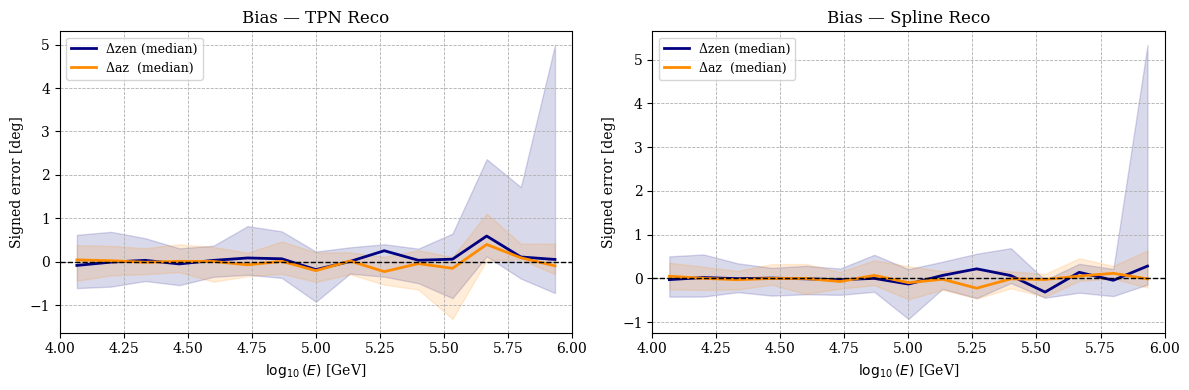

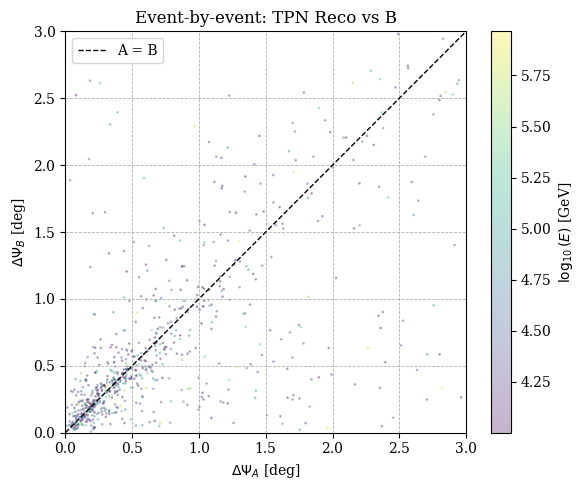

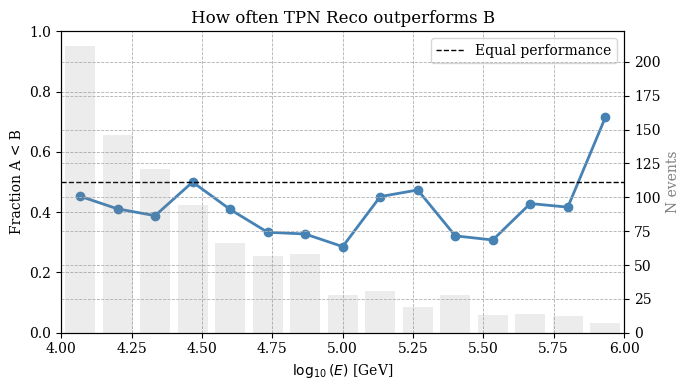

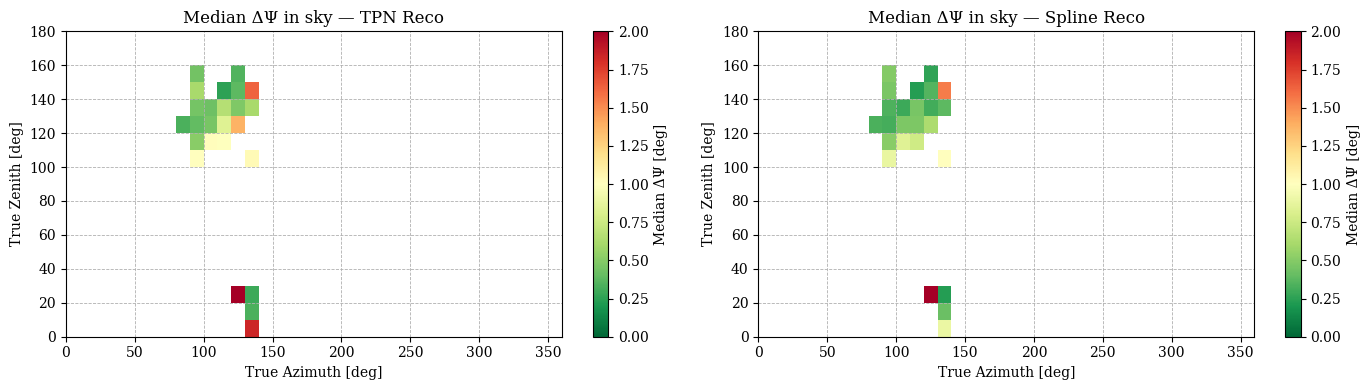

In [106]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# ── Angular separation (haversine formula, works for small and large angles) ──
def angular_sep(zen1, az1, zen2, az2):
    """All angles in radians. Returns separation in degrees."""
    dphi = az1 - az2
    cos_angle = (np.cos(zen1) * np.cos(zen2) +
                 np.sin(zen1) * np.sin(zen2) * np.cos(dphi))
    cos_angle = np.clip(cos_angle, -1, 1)  # numerical safety
    return np.degrees(np.arccos(cos_angle))

# ── Compute angular errors ────────────────────────────────────────────────────
# Adjust column names to match your dataframe
zen_true = true_zen
az_true  =  true_az
zen_A    = reco_zen 
az_A     = reco_az
zen_B    = seed_zen
az_B     = seed_az

dpsi_A  = angular_sep(zen_A, az_A, zen_true, az_true)   # error of TPN Reco
dpsi_B  = angular_sep(zen_B, az_B, zen_true, az_true)   # error of Spline Reco
dpsi_AB = angular_sep(zen_A, az_A, zen_B, az_B)         # opening angle A vs B

log_energy = np.log10(df['neutrino_energy'])

# ── Bias components: signed error in zenith and azimuth separately ────────────
# Useful for detecting systematic pointing offsets
dzen_A = np.degrees(zen_A - zen_true)
dzen_B = np.degrees(zen_B - zen_true)

# Azimuth difference wrapped to [-180, 180]
def wrap_daz(az1, az2):
    d = np.degrees(az1 - az2)
    return (d + 180) % 360 - 180

daz_A = wrap_daz(az_A, az_true)
daz_B = wrap_daz(az_B, az_true)

# ── Binning setup ─────────────────────────────────────────────────────────────
e_bins    = np.linspace(4, 6, 16)
e_centers = 0.5 * (e_bins[:-1] + e_bins[1:])
e_widths  = np.diff(e_bins)

dpsi_bins    = np.linspace(0, 3, 61)
dpsi_centers = 0.5 * (dpsi_bins[:-1] + dpsi_bins[1:])
dpsi_widths  = np.diff(dpsi_bins)

def quantiles(vals, energy, bins, qs=[10, 50, 90]):
    out = [[] for _ in qs]
    for el, eh in zip(bins[:-1], bins[1:]):
        idx = (energy >= el) & (energy < eh)
        if idx.sum() == 0:
            for o in out: o.append(np.nan)
        else:
            pcts = np.percentile(vals[idx], qs)
            for o, p in zip(out, pcts): o.append(p)
    return [np.array(o) for o in out]

def conditional_pdf(dpsi, log_e, e_bins, dpsi_bins):
    H, _, _ = np.histogram2d(log_e, dpsi, bins=[e_bins, dpsi_bins])
    dpsi_w  = np.diff(dpsi_bins)
    marg    = np.sum(H * dpsi_w[None, :], axis=1, keepdims=True)
    marg[marg == 0] = np.nan
    return H / marg

# ═══════════════════════════════════════════════════════════════════════════════
# PLOT 1: Resolution vs energy — A vs B (10/50/90th percentile bands)
# ═══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(7, 4))
for dpsi, label, color in [(dpsi_A, 'TPN Reco', 'steelblue'),
                            (dpsi_B, 'Spline Reco', 'tomato')]:
    lo, med, hi = quantiles(dpsi, log_energy, e_bins)
    ax.fill_between(e_centers, lo, hi, alpha=0.15, color=color)
    ax.plot(e_centers, med, color=color, lw=2,   label=f'{label} — 50th')
    ax.plot(e_centers, lo,  color=color, lw=1, ls='--', label=f'{label} — 10th')
    ax.plot(e_centers, hi,  color=color, lw=1, ls=':',  label=f'{label} — 90th')
ax.set(xlabel=r'$\log_{10}(E)$ [GeV]', ylabel=r'$\Delta\Psi$ [deg]',
       title='Angular Resolution vs Energy', xlim=[4, 6], ylim=[0, 3])
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# PLOT 2: 2D Conditional PDF  P(ΔΨ | E) — side by side
# ═══════════════════════════════════════════════════════════════════════════════
X, Y = np.meshgrid(e_centers, dpsi_centers)
norm = matplotlib.colors.Normalize(vmin=0, vmax=3)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, dpsi, title in zip(axes, [dpsi_A, dpsi_B], ['TPN Reco', 'Spline Reco']):
    C  = conditional_pdf(dpsi, log_energy, e_bins, dpsi_bins)
    pc = ax.pcolormesh(X, Y, C.T, norm=norm, shading='auto', cmap='viridis')
    # overlay median
    _, med, _ = quantiles(dpsi, log_energy, e_bins)
    ax.plot(e_centers, med, color='white', lw=1.5, ls='--', label='Median')
    ax.set(xlabel=r'$\log_{10}(E)$ [GeV]', ylabel=r'$\Delta\Psi$ [deg]',
           title=f'P(ΔΨ | E) — {title}')
    ax.legend(fontsize=8)
plt.colorbar(pc, ax=axes.tolist(), label=r'P($\Delta\Psi$ | E) [deg$^{-1}$]')
plt.tight_layout(); plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# PLOT 3: Bias — median signed error in zenith and azimuth vs energy
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, (dzen, daz, label, color) in zip(
        axes,
        [(dzen_A, daz_A, 'TPN Reco', 'steelblue'),
         (dzen_B, daz_B, 'Spline Reco', 'tomato')]):
    _, med_zen, _ = quantiles(dzen, log_energy, e_bins, qs=[25, 50, 75])
    _, med_az,  _ = quantiles(daz,  log_energy, e_bins, qs=[25, 50, 75])
    lo_zen, med_zen, hi_zen = quantiles(dzen, log_energy, e_bins, qs=[25, 50, 75])
    lo_az,  med_az,  hi_az  = quantiles(daz,  log_energy, e_bins, qs=[25, 50, 75])
    ax.fill_between(e_centers, lo_zen, hi_zen, alpha=0.15, color='navy')
    ax.fill_between(e_centers, lo_az,  hi_az,  alpha=0.15, color='darkorange')
    ax.plot(e_centers, med_zen, color='navy',       lw=2, label='Δzen (median)')
    ax.plot(e_centers, med_az,  color='darkorange', lw=2, label='Δaz  (median)')
    ax.axhline(0, color='k', ls='--', lw=1)
    ax.set(xlabel=r'$\log_{10}(E)$ [GeV]', ylabel='Signed error [deg]',
           title=f'Bias — {label}', xlim=[4, 6])
    ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# PLOT 4: Event-by-event scatter ΔΨ_A vs ΔΨ_B, colored by log energy
# ═══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(dpsi_A, dpsi_B, c=log_energy, s=1, alpha=0.3,
                cmap='viridis', rasterized=True)
lim = min(max(np.percentile(dpsi_A, 99), np.percentile(dpsi_B, 99)), 3.0)
ax.plot([0, lim], [0, lim], 'k--', lw=1, label='A = B')
plt.colorbar(sc, ax=ax, label=r'$\log_{10}(E)$ [GeV]')
ax.set(xlabel=r'$\Delta\Psi_A$ [deg]', ylabel=r'$\Delta\Psi_B$ [deg]',
       title='Event-by-event: TPN Reco vs B', xlim=[0, lim], ylim=[0, lim])
ax.legend(); plt.tight_layout(); plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# PLOT 5: Fraction of events where A beats B, vs energy
# ═══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(7, 4))
frac, n_events = [], []
for el, eh in zip(e_bins[:-1], e_bins[1:]):
    idx = (log_energy >= el) & (log_energy < eh)
    n   = idx.sum()
    frac.append(np.mean(dpsi_A[idx] < dpsi_B[idx]) if n else np.nan)
    n_events.append(n)
ax.plot(e_centers, frac, 'o-', color='steelblue', lw=2)
ax.axhline(0.5, color='k', ls='--', lw=1, label='Equal performance')
ax.set(xlabel=r'$\log_{10}(E)$ [GeV]', ylabel='Fraction A < B',
       title='How often TPN Reco outperforms B', xlim=[4, 6], ylim=[0, 1])
# secondary axis: event counts
ax2 = ax.twinx()
ax2.bar(e_centers, n_events, width=e_widths*0.8, alpha=0.15, color='gray')
ax2.set_ylabel('N events', color='gray')
ax.legend(); plt.tight_layout(); plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# PLOT 6: 2D bias map — median Δzen vs Δaz in zenith/azimuth space
#         (shows if bias has directional dependence)
# ═══════════════════════════════════════════════════════════════════════════════
zen_bins = np.linspace(0,  180, 19)
az_bins  = np.linspace(0,  360, 37)
zen_c    = 0.5 * (zen_bins[:-1] + zen_bins[1:])
az_c     = 0.5 * (az_bins[:-1]  + az_bins[1:])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, dpsi, dzen, daz, title in zip(
        axes,
        [dpsi_A, dpsi_B],
        [dzen_A, dzen_B],
        [daz_A,  daz_B],
        ['TPN Reco', 'Spline Reco']):
    zen_deg = np.degrees(zen_true)
    az_deg  = np.degrees(az_true)
    H = np.full((len(zen_c), len(az_c)), np.nan)
    for i, (zl, zh) in enumerate(zip(zen_bins[:-1], zen_bins[1:])):
        for j, (al, ah) in enumerate(zip(az_bins[:-1], az_bins[1:])):
            mask = (zen_deg >= zl) & (zen_deg < zh) & (az_deg >= al) & (az_deg < ah)
            if mask.sum() > 5:
                H[i, j] = np.median(dpsi[mask])
    AZ, ZEN = np.meshgrid(az_c, zen_c)
    pc = ax.pcolormesh(AZ, ZEN, H, shading='auto', cmap='RdYlGn_r',
                       vmin=0, vmax=2)
    ax.set(xlabel='True Azimuth [deg]', ylabel='True Zenith [deg]',
           title=f'Median ΔΨ in sky — {title}')
    plt.colorbar(pc, ax=ax, label='Median ΔΨ [deg]')
plt.tight_layout(); plt.show()